In [1]:
from __future__ import annotations

import yaml
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

idx = pd.IndexSlice

In [92]:
with open(Path.cwd().parent / 'config' / 'plotting.default.yaml', 'r') as f:
    tech_colors = yaml.safe_load(f)['plotting']['tech_colors']

# inplace update: give these gas-ish techs a more diverse palette (not all brown)
tech_colors.update({
    "SMR CC":                        "#1f77b4",  # blue
    "heat100-200 industry gas":      "#ff7f0e",  # orange
    "heat<100 industry gas":         "#2ca02c",  # green
    "Combined-Cycle Gas":            "#d62728",  # red
    "Open-Cycle Gas":                "#9467bd",  # purple
    "heat200-500 industry gas":      "#17becf",  # cyan
    "H2 electrolysis":               "#e377c2",  # pink
    "urban central gas boiler":      "#7f7f7f",  # grey
    "urban central gas CHP":         "#bcbd22",  # olive
    "rural gas boiler":              "#8c564b",  # brown (keep one brown, but not all)
    "urban decentral gas boiler":    "#aec7e8",  # light blue
    "urban decentral biomass boiler":"#92648c",  # purple
    "rural biomass boiler":          "#94312c",  # purple
    "heat>500 industry gas":         "#98df8a",  # light green
    "gas DRI":                       "#000000",  # black

    # Additions reflecting explicit categories from the picture/code:
    # (assigning suitable colors, some re-using for semantic consistency)
    ">500C industry heat and feedstock": "#17becf",   # tan/grayish
    "<500C industry heat":               "#98df8a",   # brown (matches rural gas boiler)
    "biomethane":                        "gold",   # teal
    "hydrogen heating":               "magenta",   # pink (matches SMR)
    "building heat":                  "#94312c",   # grey (matches urban central gas boiler)
    "electricity":                  "#d62728",   # red (matches Combined-Cycle Gas)
})
tech_colors['residential gas boiler'] = tech_colors['urban decentral gas boiler']
tech_colors['gas turbine'] = tech_colors['Open-Cycle Gas']
tech_colors['wind'] = tech_colors['Onshore Wind']
tech_colors['solar'] = tech_colors['solar-hsat']
tech_colors['biomass buildings'] = tech_colors['urban decentral biomass boiler']
tech_colors['biomass industry'] = tech_colors['heat200-500 industry solid biomass']
tech_colors['building heat pump'] = tech_colors['air heat pump']
tech_colors['industrial heat pump'] = tech_colors['heat<100 industry industrial heat pump medium temperature']


In [68]:
nb = pd.read_csv(
    Path.cwd().parent / 'results' / 'csvs_3_latest' / 'nodal_energy_balance.csv', index_col=list(range(4)), header=list(range(5))
).loc[:,idx[:,:,:,'free']]
nb.columns = nb.columns.get_level_values(-1).astype(int)

In [69]:
bal = pd.read_csv(
    Path.cwd().parent / 'results' / 'csvs_3_latest' / 'energy_balance.csv', index_col=list(range(3)), header=list(range(5))
).loc[:, idx[:,:,:,'free']]
bal.columns = bal.columns.get_level_values(-1).astype(int)

In [70]:
mp = pd.read_csv(
    Path.cwd().parent / 'results' / 'csvs_3_latest' / 'prices.csv', index_col=list(range(1)), header=list(range(5))
).loc[:, idx[:,:,:,'free']]
mp.columns = mp.columns.get_level_values(-1).astype(int)

gas_price = mp.loc['gas']
gas_price.index = gas_price.index.get_level_values(-1)

In [71]:
idx = pd.IndexSlice
gas = bal.loc[idx[:, :, 'gas']]

gascon = gas.loc[gas.sum(axis=1) < 0].abs().mul(1e-6)
gascon.index = gascon.index.droplevel(0)
gascon = gascon.sort_values(gascon.columns[-1])

gasgen = gas.loc[gas.sum(axis=1) > 0].mul(1e-6)
gasgen.index = gasgen.index.droplevel(0)

In [72]:
ref = gascon.iloc[:,-1]
dis = gascon.iloc[:,:-1]

threshold_share = 0.5
gasuse_baseline = mp.columns[-1] # TWh

displaced = dis.sub(ref, axis=0).abs()

df = pd.DataFrame(index=displaced.index, columns=['phase_out_prices', 'phase_out_volume'])

for carrier in displaced.index:

    ss = displaced.loc[carrier]
    ss = ss[ss > threshold_share * ss.max()]

    if not len(ss):
        continue

    df.loc[carrier, 'phase_out_prices'] = mp.loc['gas', ss.index[-1]]
    df.loc[carrier, 'phase_out_volume'] = gasuse_baseline - ss.index[-1]

df.sort_values(by='phase_out_prices', ascending=True, inplace=True)
df.dropna(inplace=True)

ignored = [
    'gas for industry CC',
    'gas for industry',
    ]

df.drop(ignored, inplace=True)

df['gas_consumption'] = gasuse_baseline - df['phase_out_volume']
xlim_lower = 1000
xlim_upper = 4000

##### energy balances

In [73]:
costs = pd.read_csv(
    Path.cwd().parent / 'results' / 'csvs_3_latest' / 'costs.csv', index_col=list(range(3)), header=list(range(5))
).sum().mul(1e-9)
costs.index = costs.index.get_level_values(-1)
# Interpolate value for 1750 instead of dropping it
if '1750' in costs.index:
    i = costs.index.get_loc('1750')
    if i > 0 and i < len(costs) - 1:
        prev_val = costs.iloc[i - 1]
        next_val = costs.iloc[i + 1]
        costs.iloc[i] = (prev_val + next_val) / 2
costs.name = 'System Cost [B€]'
costs.index.name = 'Gas Consumption [TWh/a]'

In [74]:
items = [
    # "heat>500 industry gas CC",
    "gas for industry",
    "heat>500 industry gas",
    "heat200-500 industry gas",
    # "gas for industry CC",
    # "Open-Cycle Gas",
    # "Combined-Cycle Gas",
    "gas turbine",
    "residential gas boiler",
    "urban central gas CHP",
    # "SMR CC",
    "SMR",
    "heat<100 industry gas",
    "heat100-200 industry gas",
    "biogas to gas",
]

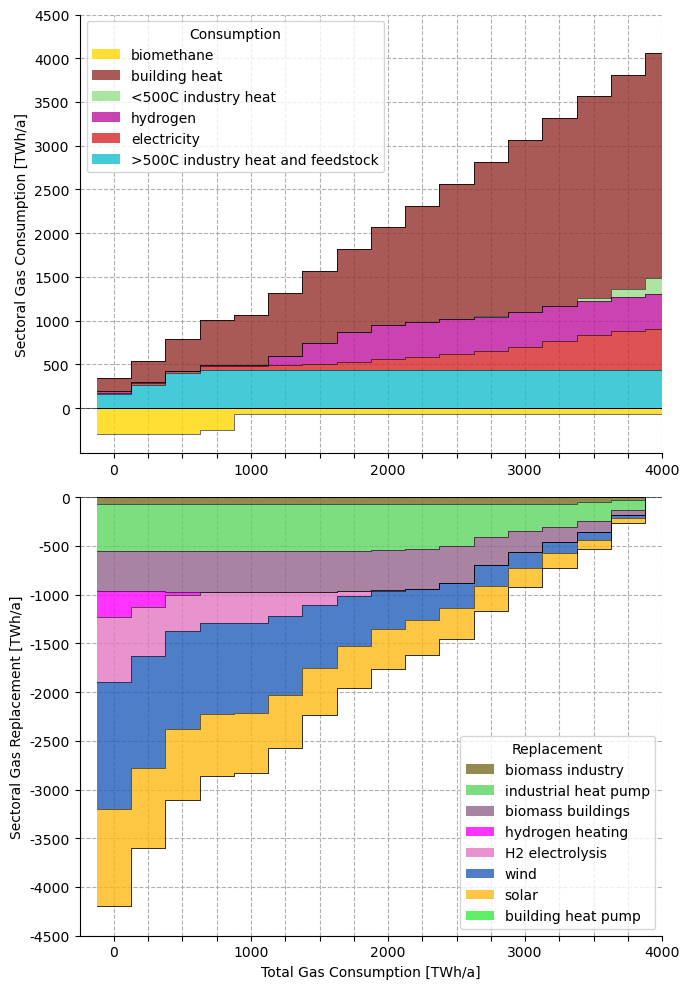

In [116]:
gb = bal.loc[:,:,'gas'].mul(1e-6)
gb.index = gb.index.get_level_values(1)
gb.drop('gas', inplace=True)

# print(gb.index)

carrier_mapping = {
    'gas for industry': '>500C industry heat and feedstock',
    'heat>500 industry gas': '>500C industry heat and feedstock',
    'heat200-500 industry gas': '<500C industry heat',
    'heat100-200 industry gas': '<500C industry heat',
    'heat<100 industry gas': '<500C industry heat',
    'biogas to gas': 'biomethane',
    'SMR': 'hydrogen',
    'urban decentral gas boiler': 'building heat',
    'urban central gas boiler': 'building heat',
    'urban central gas CHP': 'building heat',
    'rural gas boiler': 'building heat',
    'Open-Cycle Gas': 'electricity',
    'Combined-Cycle Gas': 'electricity',
}

# items = list(set(carrier_mapping.values()))

# the sorting should be manual
items = [
    '>500C industry heat and feedstock',
    'electricity',
    'hydrogen',
    '<500C industry heat',
    'building heat',
    'biomethane',
]

# for carrier in items:
#     if carrier in carrier_mapping:
        # continue

    # carrier_mapping[carrier] = carrier_mapping.get(carrier, carrier)

gb = gb.groupby(carrier_mapping).sum()

line_kwargs = {
    'color': 'k',
    'linewidth': 0.5,
    'alpha': 0.8
}


fig, axs = plt.subplots(2, 1, figsize=(7, 10))

axs[0].axhline(0, **line_kwargs)

bottoms = pd.Series(0, index=gb.columns, dtype=float)
ceilings = pd.Series(0, index=gb.columns, dtype=float)

width = 1

for i, carrier in enumerate(items):

    row = gb.loc[carrier]
    
    for j, con in enumerate(row.index):

        value = row.loc[con] * (-1)

        if value < 0:

            axs[0].bar(
                j + width/2,
                value,
                bottom=ceilings.loc[con],
                color=tech_colors[carrier],
                alpha=0.8,
                width=1
                )
            ceilings.loc[con] += value

        else:

            axs[0].bar(
                j + width/2,
                value,
                bottom=bottoms.loc[con],
                color=tech_colors[carrier],
                alpha=0.8,
                width=1
            )

            bottoms.loc[con] += value
    
    axs[0].step(
        np.arange(len(bottoms) + 1),  # extend by one to the right
        np.append(bottoms.values, bottoms.values[-1]),
        where='post',
        **line_kwargs
    )
    axs[0].step(
        np.arange(len(bottoms) + 1),  # extend by one to the right
        np.append(ceilings.values, ceilings.values[-1]),
        where='post',
        **line_kwargs
    )

axs[0].set_xlim(-width/2, len(bottoms) - width/2)
axs[0].spines['right'].set_visible(False)
axs[0].spines['top'].set_visible(False)
axs[0].grid(linestyle='--', alpha=1)
axs[0].set_axisbelow(True)

axs[0].set_xticks(np.arange(len(bottoms)) + width/2)
axs[0].set_xticklabels(
    [label if i % 4 == 0 else '' for i, label in enumerate(bottoms.index)],
    rotation=0
)

# Add legend on the right side
handles = []
labels = []
for carrier in items[::-1]:
    if carrier == 'biogas to gas':
        continue

    if carrier in tech_colors:
        handles.append(plt.Rectangle((0, 0), 1, 1, fc=tech_colors[carrier], alpha=0.8))
        labels.append(carrier)

from matplotlib.lines import Line2D

# handles.append(Line2D([0], [0], color='w', lw=0.5, alpha=0.8))
# labels.append('')
# labels.append('biogas to gas')
# handles.append(plt.Rectangle((0, 0), 1, 1, fc=tech_colors['biogas to gas'], alpha=0.8))

# axs[0].legend(handles, labels, loc='center left', bbox_to_anchor=(-0.1, 1.1), frameon=False, ncol=3)
axs[0].legend(handles, labels, loc='upper left', frameon=True, ncol=1, title='Consumption')

axs[0].set_xlabel('')
axs[0].set_ylabel('Sectoral Gas Consumption [TWh/a]')

axs[0].spines['top'].set_visible(False)

'''
ax2 = axs[0].twinx()

y1_min, y1_max = axs[0].get_ylim()

if y1_min < 0 < y1_max:
    zero_fraction = -y1_min / (y1_max - y1_min)
else:
    zero_fraction = 0  # If y=0 is not in range, default to bottom

gas_price_min = gas_price.min()
gas_price_max = gas_price.max()

y2_max = gas_price_max * 1.1  # Add 10% padding at the top

if zero_fraction < 1:
    y2_min = -zero_fraction * y2_max / (1 - zero_fraction)
else:
    y2_min = gas_price_min * 0.9  # Fallback if zero_fraction is 1

ax2.plot(np.arange(len(gas_price)) + width/2, gas_price.values, color='red', linewidth=4, marker='o', markersize=8)
ax2.plot(np.arange(len(gas_price)) + width/2, gas_price.values, color='w', linewidth=1, marker='o', markersize=3)
ax2.set_xlim(0, len(bottoms))
ax2.set_ylim(y2_min, y2_max)
ax2.set_ylabel('Gas Price [€/MWh]', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add third y-axis for costs
ax3 = axs[0].twinx()

# Offset the third axis to the right
ax3.spines['right'].set_position(('outward', 60))

costs_min = costs.min()
costs_max = costs.max()

y3_max = costs_max * 1.1  # Add 10% padding at the top

if zero_fraction < 1:
    y3_min = -zero_fraction * y3_max / (1 - zero_fraction)
else:
    y3_min = costs_min * 0.9  # Fallback if zero_fraction is 1

cost_color = 'forestgreen'
# ax3.plot(np.arange(len(costs)) + width/2, costs.values, color=cost_color, linewidth=2, marker='o', markersize=4)
ax3.plot(np.arange(len(costs)) + width/2, costs.values, color=cost_color, linewidth=4, marker='o', markersize=8)
ax3.plot(np.arange(len(costs)) + width/2, costs.values, color='w', linewidth=1, marker='o', markersize=3)
ax3.set_xlim(0, len(bottoms))
ax3.set_ylim(y3_min, y3_max)
ax3.set_ylabel('System Cost [B€]', color=cost_color)
ax3.tick_params(axis='y', labelcolor=cost_color)
'''

target_bus_carriers = {
    "Hydrogen Storage": ["SMR"],
    "AC": ["Combined-Cycle Gas", "Open-Cycle Gas"],
    "gas": ["Sabatier"],
    "biogas": ["biogas to gas"],
    "gas for industry": ["gas for industry", "gas for industry CC"],
    "heat100-200 industry": ["heat100-200 industry gas"],
    "heat200-500 industry": ["heat200-500 industry gas"],
    "heat<100 industry": ["heat<100 industry gas"],
    "heat>500 industry": ["heat>500 industry gas"],
    "rural heat": ["rural gas boiler"],
    "urban central heat": ["urban central gas CHP", "urban central gas boiler"],
    "urban decentral heat": ["urban decentral gas boiler"],
}

gb = bal.loc[:,:,'gas'].mul(1e-6)
gb.index = gb.index.get_level_values(1)
gb.drop('gas', inplace=True)

# gb = bal.loc[:,:,'gas'].mul(1e-6)

threshold = 10 # TWh

displacers = []

# for bus_carrier, gas_carrier in gb.index:
for bus_carrier, gas_carriers in target_bus_carriers.items():
# for carrier in ['heat100-200 industry gas']:

    # if carrier in ['gas for industry', 'gas for industry CC', 'Sabatier']:
    #     continue

    # target_carrier = target_bus_carriers[carrier]

    ss = bal.loc[idx[:,:,bus_carrier]] / 1e6
    # print(ss)
    ss.index = ss.index.droplevel(0)

    maxgas_col = ss.loc[gas_carriers].sum().idxmax()

    diff = ss.sub(ss.loc[:,maxgas_col], axis=0).drop(gas_carriers)
    # print()
    diff = diff.loc[diff.sum(axis=1) > threshold]

    # print(bus_carrier)
    # print(gas_carriers)
    # print(diff.index)
    # print('===================================')

    displacers.append(diff)

df = pd.concat(displacers)
df = df.drop(df.index.intersection(gb.index))
df.index

ground_hp_names = df.index[df.index.str.contains('ground heat pump')]
df.loc['ground heat pump'] = df.loc[ground_hp_names].sum(axis=1)
df.drop(ground_hp_names, inplace=True)

air_hp_names = df.index[df.index.str.contains('air heat pump')]
df.loc['air heat pump'] = df.loc[air_hp_names].sum(axis=1)
df.drop(air_hp_names, inplace=True)

solar_thermal_names = df.index[df.index.str.contains('solar thermal')]
df.loc['solar thermal'] = df.loc[solar_thermal_names].sum(axis=1)
df.drop(solar_thermal_names, inplace=True)

# df.drop(['gas', 'biogas'], inplace=True)

df = df.groupby(df.index).sum()

df.index
df.drop('gas pipeline', inplace=True)

sorted_displacers_index = [
    # "biogas to gas",
    # "Fischer-Tropsch",
    # "electrobiofuels",
    "heat<100 industry industrial heat pump medium temperature",
    "heat100-200 industry industrial heat pump high temperature",
    "battery discharger",
    "air heat pump",
    "ground heat pump",
    "urban central solid biomass CHP",
    "urban decentral biomass boiler",
    "rural biomass boiler",
    "heat200-500 industry solid biomass",
    # "electrobiofuels",
    "H2 Electrolysis",
    "Offshore Wind (AC)",
    "Offshore Wind (DC)",
    # "Offshore Wind (Floating)",
    "Onshore Wind",
    # "Solar",
    "solar-hsat",
    "solar thermal",
    # "heat200-500 industry hydrogen",
    "heat>500 industry hydrogen",
]

tech_to_group = {
    # Wind
    "Onshore Wind": "wind",
    "Offshore Wind (DC)": "wind",
    "Offshore Wind (AC)": "wind",

    # Solar
    "solar-hsat": "solar",
    "solar thermal": "solar",

    # Biomass
    "urban decentral biomass boiler": "biomass buildings",
    "urban central solid biomass CHP": "biomass buildings",
    "rural biomass boiler": "biomass buildings",

    "heat200-500 industry solid biomass": "biomass industry",

    # Building heat pumps
    "ground heat pump": "building heat pump",
    "air heat pump": "building heat pump",

    # Industrial heat pumps
    "heat<100 industry industrial heat pump medium temperature": "industrial heat pump",
    "heat100-200 industry industrial heat pump high temperature": "industrial heat pump",

    # Electrolysis / hydrogen
    "H2 Electrolysis": "H2 electrolysis",
    "heat>500 industry hydrogen": "hydrogen heating",

    # Battery
    "battery discharger": "battery",
}

sorting = [
    'biomass industry',
    'industrial heat pump',
    'biomass buildings',
    'hydrogen heating',
    'H2 electrolysis',
    'wind',
    'solar',
    'building heat pump',
]

line_kwargs = {
    'color': 'k',
    'linewidth': 0.5,
    'alpha': 0.8
}

axs[1].axhline(0, **line_kwargs)

bottoms = pd.Series(0, index=df.columns, dtype=float)
ceilings = pd.Series(0, index=df.columns, dtype=float)

width = 1

# assert df.index.symmetric_difference(sorted_displacers_index).empty, df.index.symmetric_difference(sorted_displacers_index)

df_plot = df.copy().groupby(tech_to_group).sum()

#for i, carrier in enumerate(sorted_displacers_index):
for i, carrier in enumerate(sorting):

    row = df_plot.loc[carrier]
    
    for j, con in enumerate(row.index):

        value = row.loc[con] * (-1)

        if value < 0:

            axs[1].bar(
                j + width/2,
                value,
                bottom=ceilings.loc[con],
                color=tech_colors[carrier],
                alpha=0.8,
                width=1
                )
            ceilings.loc[con] += value

        else:

            axs[1].bar(
                j + width/2,
                value,
                bottom=bottoms.loc[con],
                color=tech_colors[carrier],
                alpha=0.8,
                width=1
            )

            bottoms.loc[con] += value

    axs[1].step(
        np.arange(len(bottoms)),
        bottoms.values,
        where='post',
        **line_kwargs
    )
    axs[1].step(
        np.arange(len(bottoms)),
        ceilings.values,
        where='post',
        **line_kwargs
    )

axs[1].set_xlim(-width/2, len(bottoms) - width/2)
axs[1].spines['right'].set_visible(False)
axs[1].spines['top'].set_visible(False)
axs[1].grid(linestyle='--', alpha=1)
axs[1].set_axisbelow(True)

axs[1].set_xticks(np.arange(len(bottoms)) + width/2)
axs[1].set_xticklabels(
    [label if i % 4 == 0 else '' for i, label in enumerate(bottoms.index)],
    rotation=0
)

# Add legend on the right side
handles = []
labels = []
# for carrier in df.index[::-1]:
for carrier in sorting:
    if carrier == 'biogas to gas':
        continue

    if carrier in tech_colors:
        handles.append(plt.Rectangle((0, 0), 1, 1, fc=tech_colors[carrier], alpha=0.8))
        labels.append(carrier)


axs[1].legend(handles, labels, loc='lower right', frameon=True, ncol=1, title='Replacement')

axs[1].set_xlabel('Total Gas Consumption [TWh/a]')
axs[1].set_ylabel('Sectoral Gas Replacement [TWh/a]')

for sign, ax in zip([1, -1], axs):
    ax.set_yticks([sign * 500 * i for i in range(0, 10)])
    ax.set_yticklabels([f'{sign * 500 * i}' for i in range(0, 10)])

# plt.savefig('gas_use_by_sector.pdf', bbox_inches='tight')
plt.tight_layout()
plt.show()